# DATA5000 Workshop #2 Notebook on Forecasting

# ***NeuralProphet:***

## https://neuralprophet.com/

# ***Presentation***
## https://github.com/ourownstory/neural_prophet/blob/main/notes/NeuralProphet_Introduction.pdf

### ***The research paper:***
## https://arxiv.org/abs/2111.15397

### ***Facebook Prophet***, which set an industry standard for explainable, scalable, and user-friendly forecasting frameworks: https://facebook.github.io/prophet/

### But Prophet is a statistical method - NOT a Neural Network-based Model

### ***Prophet*** also lacks understanding of "local context": which is essential for forecasting the near-term future.

### The lack of local context, which is essential for forecasting the nearterm future, has restricted the usefulness of Prophet in industrial applications.


### ***Readings***:

* https://towardsdatascience.com/in-depth-understanding-of-neuralprophet-through-a-complete-example-2474f675bc96

* https://towardsdatascience.com/prophet-vs-neuralprophet-fc717ab7a9d8


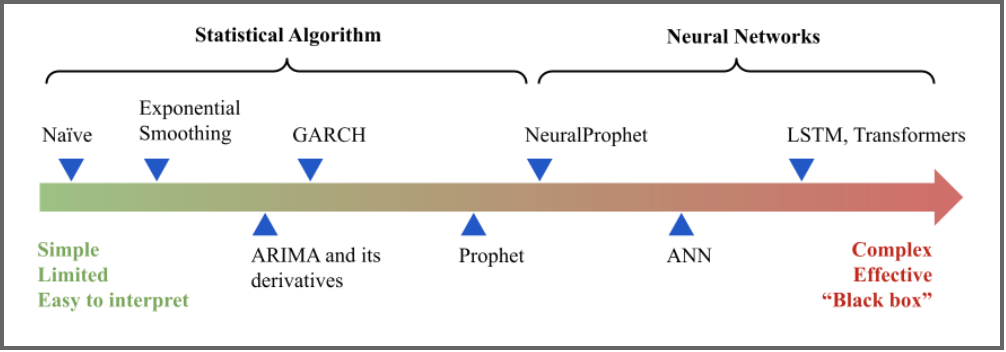

#***LOCAL CONTEXT***

### ***A local context is:*** the near-term future depends on the current state of the system. The majority of time series forecasting exhibits those dynamics, evidenced in scenarios related to energy consumption, traffic patterns, air quality measures, and much more. For example, when there’s a strong uptick in server load, it might have been triggered by a recent event that could continue for prolonged periods, which should be reflected in near-term forecasts.

### For short to medium-term forecasts, NeuralProphet improves forecast accuracy by 55 to 92 percent

## What is a Neural Network? https://www.ibm.com/cloud/learn/neural-networks

# ***TIME IN NEURAL PROPHET***
### Pandas Time Series: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases

#***What is a Neural Network?***
## What is a Neural Network? https://www.ibm.com/cloud/learn/neural-networks

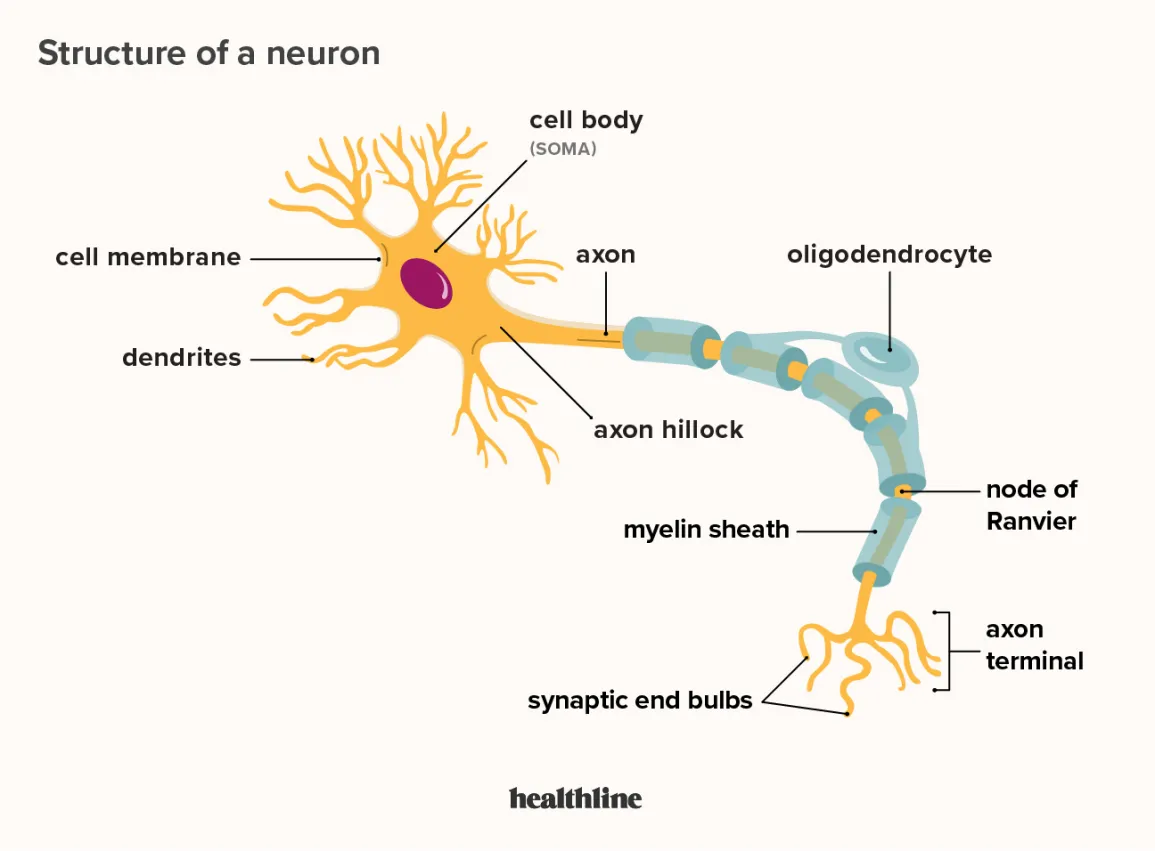

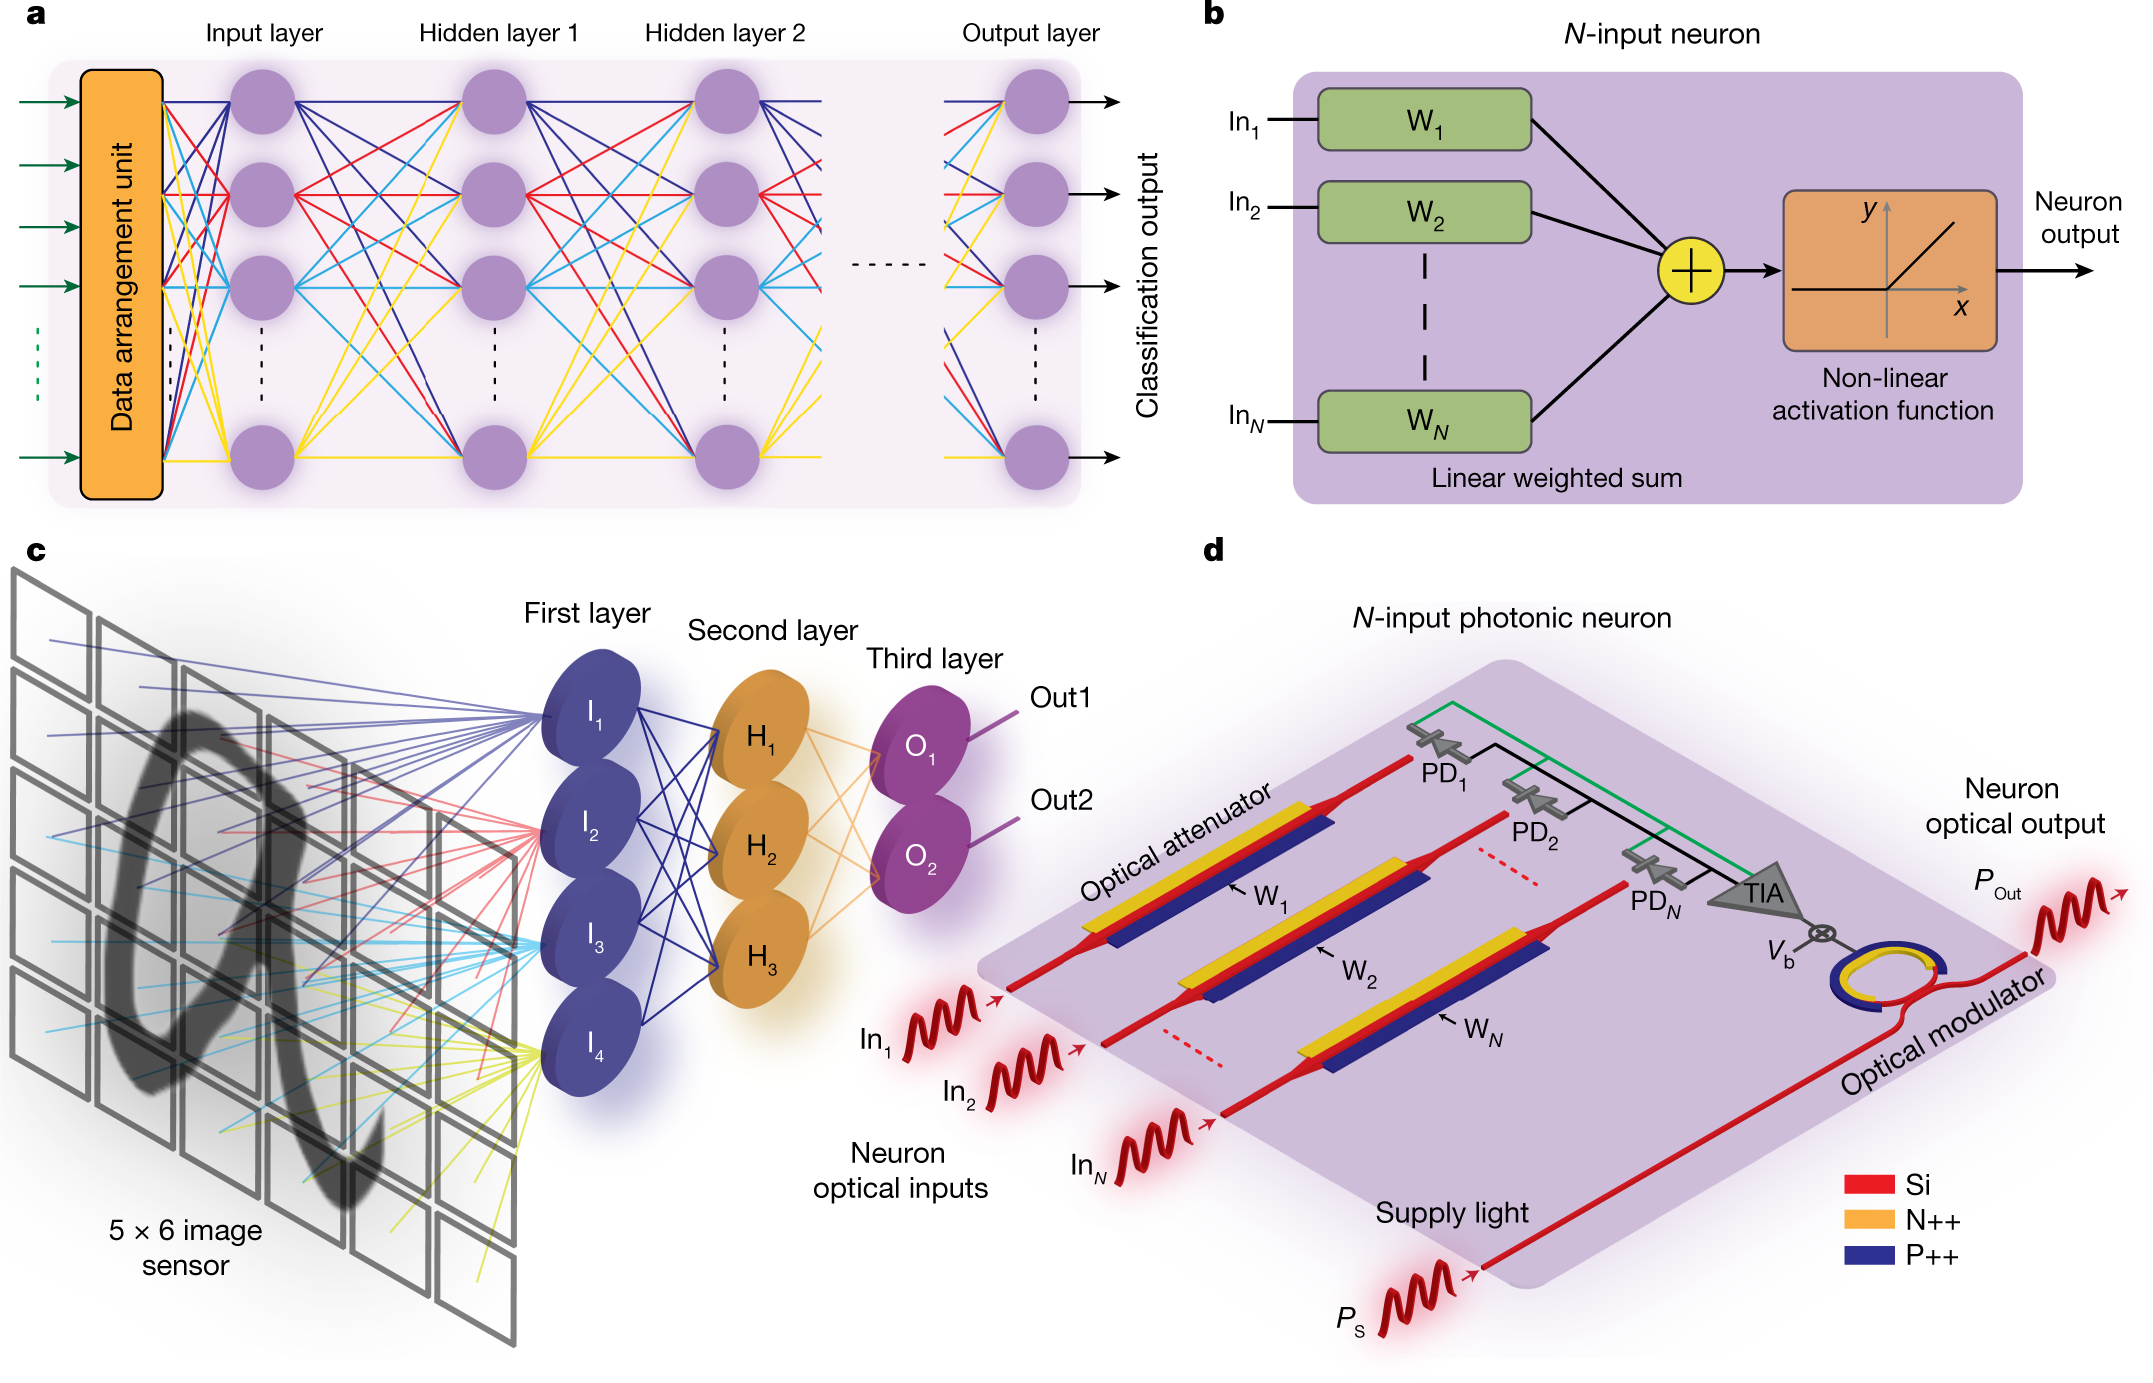

# ***Running NeuralProphet***

In [10]:
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

# STEP 1: Install Libraries

We start by installing everything that won't work with NeuralProphet

In [11]:
!pip uninstall -y tensorflow torch torchvision torchaudio opencv-python numpy opencv-contrib-python opencv-python-headless albucore albumentations dopamine-rl captum numba datasets gcsfs gradio

Found existing installation: torch 2.3.1+cu121
Uninstalling torch-2.3.1+cu121:
  Successfully uninstalled torch-2.3.1+cu121
Found existing installation: torchvision 0.18.1+cu121
Uninstalling torchvision-0.18.1+cu121:
  Successfully uninstalled torchvision-0.18.1+cu121
Found existing installation: torchaudio 2.3.1+cu121
Uninstalling torchaudio-2.3.1+cu121:
  Successfully uninstalled torchaudio-2.3.1+cu121
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: captum 0.8.0
Uninstalling captum-0.8.0:
  Successfully uninstalled captum-0.8.0


In [12]:
!pip install --no-cache-dir --force-reinstall numpy==1.26.4
!pip install --no-cache-dir --force-reinstall torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 156.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 277.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchmetrics 1.8.2 requires torch>=2.0.0, which is not installed.
neuralprophet 1.0.0rc10 requires captum>=0.6.0, which is not installed.
neuralprophet 1.0.0rc10 requires torch>=2.0.0, which is not installed.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, which is not installed.
librosa 0.11.0 requires numba>=0.51.0, which is not installed.
stumpy 1.13.0 requires numba>=0.57.1, which is not installed.
peft 0.18.0 requires torch>=1.13.0, which is not installed.
accelerate 1.12.0 requires torch>=2.0.0, which is not installed.
torchtune 0.6.1 requires datasets, which is not installed.
pynndescent 0.6.0 requires numba>=0.55.0, which is not ins

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 300.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 120.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 207.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 347.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 397.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 281.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 260.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 161.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 218.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 263.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 285.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

In [13]:
!pip install --no-cache-dir --force-reinstall kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 168.0 MB/s eta 0:00:00
  Attempting uninstall: kaleido
    Found existing installation: kaleido 0.2.1
    Uninstalling kaleido-0.2.1:
      Successfully uninstalled kaleido-0.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neuralprophet 1.0.0rc10 requires captum>=0.6.0, which is not installed.
neuralprophet 1.0.0rc10 requires numpy<2.0.0,>=1.25.0, but you have numpy 2.3.5 which is incompatible.


In [1]:
!pip install --no-cache-dir --pre neuralprophet==1.0.0rc10

#if "google.colab" in str(get_ipython()):
#    !pip install git+https://github.com/ourownstory/neural_prophet.git
#    # may take a while
#    #!pip install neuralprophet # much faster, but may not have the latest upgrades/bugfixes

In [2]:
from neuralprophet import __version__


ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


In [3]:
import torch
torch.__version__

'2.3.1+cu121'

In [4]:
import numpy
numpy.__version__

'1.26.4'

In [5]:
!pip install neuralprophet['live']

### Import installed libraries

In [6]:
from neuralprophet import NeuralProphet, set_log_level
set_log_level("ERROR")

In [7]:
import neuralprophet

In [8]:
import pandas as pd
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

#STEP 2: Basic NeuralProphet on Test Data

In [9]:
data_location = "https://raw.githubusercontent.com/ourownstory/neuralprophet-data/main/datasets/"
df = pd.read_csv(data_location + "wp_log_peyton_manning.csv", dayfirst=True)

In [10]:
df

,ds,y
0,2007-12-10,9.5908
1,2007-12-11,8.5196
2,2007-12-12,8.1837
3,2007-12-13,8.0725
4,2007-12-14,7.8936
...,...,...
2959,2016-01-16,7.8172
2960,2016-01-17,9.2739
2961,2016-01-18,10.3338
2962,2016-01-19,9.1259


# Create NeuralProphet

In [11]:
# epochs - how many generations to learn
example_model = NeuralProphet(quantiles=[0.02, 0.98], epochs=10)

# Model training - make sure that the frequency of the time series is correctly coded

In [12]:
example_model_metrics = example_model.fit(df, freq="D", progress='plot-all')

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alte

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr:   0%|          | 0/237 [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 64. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 20. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.




Training: |          | 0/? [00:00<?, ?it/s]

In [13]:
example_model_future = example_model.make_future_dataframe(df, periods=365, n_historic_predictions=True)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alte

In [14]:
example_model_forecast = example_model.predict(example_model_future)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alte

Predicting: |          | 0/? [00:00<?, ?it/s]

In [15]:
example_model_forecast

,ds,y,yhat1,yhat1 2.0%,yhat1 98.0%,trend,season_yearly,season_weekly
0,2007-12-10,9.5908,9.055258,7.716529,9.055258,8.356722,0.375121,0.323415
1,2007-12-11,8.5196,8.842113,7.733759,8.842113,8.356024,0.368707,0.117383
2,2007-12-12,8.1837,8.655679,7.569977,8.655679,8.355325,0.363510,-0.063157
3,2007-12-13,8.0725,8.652105,7.596164,8.652105,8.354627,0.359591,-0.062113
4,2007-12-14,7.8936,8.656884,7.558168,8.656884,8.353928,0.357213,-0.054257
...,...,...,...,...,...,...,...,...
3324,2017-01-15,NaN,8.455106,7.411758,13.331929,7.401543,1.005772,0.047792
3325,2017-01-16,NaN,8.743496,7.591068,13.747309,7.400764,1.019516,0.323215
3326,2017-01-17,NaN,8.548393,7.617669,13.393132,7.399985,1.030520,0.117887
3327,2017-01-18,NaN,8.374377,7.458637,13.210436,7.399206,1.038712,-0.063541


# Save forecast data to csv file

In [16]:
example_model_forecast.to_csv('example_model_neuralprophet_forecast.csv')

# Use Plotly to show chart of forecasts: https://plotly.com/python/setting-graph-size/


In [17]:
visual_example_model = example_model.plot(example_model_forecast)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/plot_forecast_plotly.py:100: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()

  ds = fcst["ds"].dt.to_pydatetime()



In [18]:
visual_example_model

In [19]:
import plotly.express as px

In [20]:
df_vis = example_model_forecast
fig = px.line(df_vis, x="ds", y="yhat1",
                 width=800, height=400)
fig

# ***Forecast on Project Data***

# Forecast Australian Inflation Rate

## Explaination about inflation: https://www.rba.gov.au/education/resources/explainers/inflation-and-its-measurement.html



# STEP 2: Load Data

In [22]:
url = "https://raw.githubusercontent.com/clarkian-teachings/data5k/main/week_01/aus_cpi.csv"
df = pd.read_csv(url)

In [23]:
df

,Date,AU-CPI
0,1/1/1960,2.73973
1,1/4/1960,4.10959
2,1/7/1960,4.05405
3,1/10/1960,4.00000
4,1/1/1961,4.00000
...,...,...
249,1/4/2022,6.14478
250,1/7/2022,7.26817
251,1/10/2022,7.83182
252,1/1/2023,7.02179


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    254 non-null    object 
 1   AU-CPI  254 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.1+ KB


# STEP 3: Pre-process Time Series

In [25]:
df.Date

,Date
0,1/1/1960
1,1/4/1960
2,1/7/1960
3,1/10/1960
4,1/1/1961
...,...
249,1/4/2022
250,1/7/2022
251,1/10/2022
252,1/1/2023


### Convert Date String to True Datetimes

In [26]:
df.Date = pd.to_datetime(df.Date, format='%d/%m/%Y')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    254 non-null    datetime64[ns]
 1   AU-CPI  254 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.1 KB


### Make Date the Index of the Dataset

In [28]:
df = df.set_index(df.Date)

In [29]:
df

,Date,AU-CPI
Date,,
1960-01-01,1960-01-01,2.73973
1960-04-01,1960-04-01,4.10959
1960-07-01,1960-07-01,4.05405
1960-10-01,1960-10-01,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-04-01,2022-04-01,6.14478
2022-07-01,2022-07-01,7.26817
2022-10-01,2022-10-01,7.83182


In [30]:
data = df[['Date', 'AU-CPI']]
data

,Date,AU-CPI
Date,,
1960-01-01,1960-01-01,2.73973
1960-04-01,1960-04-01,4.10959
1960-07-01,1960-07-01,4.05405
1960-10-01,1960-10-01,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-04-01,2022-04-01,6.14478
2022-07-01,2022-07-01,7.26817
2022-10-01,2022-10-01,7.83182


In [31]:
data.rename(columns={"Date":"ds", "AU-CPI":"y"}, inplace=True)

In [32]:
data

,ds,y
Date,,
1960-01-01,1960-01-01,2.73973
1960-04-01,1960-04-01,4.10959
1960-07-01,1960-07-01,4.05405
1960-10-01,1960-10-01,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-04-01,2022-04-01,6.14478
2022-07-01,2022-07-01,7.26817
2022-10-01,2022-10-01,7.83182


#STEP 4: Forecasting - Neural Network (NeuralProphet)

## Note: do not run the code immediately below - it is here only for reference on the parameters

# DO NOT RUN - this is put here to show the parameters that are available for adjustment
class neuralprophet.forecaster.NeuralProphet(growth: Literal['off', 'linear', 'discontinuous'] = 'linear',
                                             changepoints: Optional[list] = None,
                                             n_changepoints: int = 10,
                                             changepoints_range: float = 0.8,
                                             trend_reg: float = 0,
                                             trend_reg_threshold: Optional[Union[bool, float]] = False,
                                             trend_global_local: str = 'global',
                                             yearly_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             weekly_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             daily_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             seasonality_mode: Literal['additive', 'multiplicative'] = 'additive',
                                             seasonality_reg: float = 0, season_global_local: Literal['global', 'local'] = 'global',
                                             n_forecasts: int = 1,
                                             n_lags: int = 0,
                                             ar_layers: Optional[list] = [],
                                             ar_reg: Optional[float] = None,
                                             lagged_reg_layers: Optional[list] = [],
                                             learning_rate: Optional[float] = None,
                                             epochs: Optional[int] = None,
                                             batch_size: Optional[int] = None,
                                             loss_func: Union[str, torch.nn.modules.loss._Loss, Callable] = 'Huber',
                                             optimizer: Union[str, Type[torch.optim.optimizer.Optimizer]] = 'AdamW',
                                             newer_samples_weight: float = 2,
                                             newer_samples_start: float = 0.0,
                                             quantiles: List[float] = [],
                                             impute_missing: bool = True,
                                             impute_linear: int = 10,
                                             impute_rolling: int = 10,
                                             drop_missing: bool = False,
                                             collect_metrics: Union[List[str], bool, Dict[str, torchmetrics.metric.Metric]] = True,
                                             normalize: Literal['auto', 'soft', 'soft1', 'minmax', 'standardize', 'off'] = 'auto',
                                             global_normalization: bool = False,
                                             global_time_normalization: bool = True,
                                             unknown_data_normalization: bool = False,
                                             accelerator: Optional[str] = None,
                                             trainer_config: dict = {},
                                             prediction_frequency: Optional[dict] = None)

### ADAM optimiser https://keras.io/api/optimizers/adam/

In [33]:
aus_cpi_model = NeuralProphet(
    epochs = 100,
    loss_func = "Huber",
    optimizer = "AdamW"
)

In [34]:
# Use static plotly in notebooks
aus_cpi_model.set_plotting_backend("plotly-static")

### Split data into training and validation

In [35]:
# note the code for the frequency of the time series
df_train, df_val = aus_cpi_model.split_df(data, valid_p = 0.20, freq='Q')

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1170: FutureWarning:

'Q' is deprecated and will be removed in a future version, please use 'QE' instead.



'Q' is deprecated and will be removed in a future version, please use 'QE' instead.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``as

In [36]:
df_train

,ds,y
Date,,
1960-01-01,1960-01-01,2.73973
1960-04-01,1960-04-01,4.10959
1960-07-01,1960-07-01,4.05405
1960-10-01,1960-10-01,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2009-10-01,2009-10-01,2.05628
2010-01-01,2010-01-01,2.91892
2010-04-01,2010-04-01,3.12164


In [37]:
# plot
fig_df_train = px.line(df_train, x="ds", y="y",
                 width=800, height=400)
fig_df_train

# Validation data is used by NeuralProphet to measure its performance and make adjustments to parameters.

In [38]:
df_val

,ds,y
Date,,
2011-01-01,2011-01-01,3.25630
2011-04-01,2011-04-01,3.54906
2011-07-01,2011-07-01,3.41969
2011-10-01,2011-10-01,2.99278
2012-01-01,2012-01-01,1.62767
2012-04-01,2012-04-01,1.20968
2012-07-01,2012-07-01,2.00401
2012-10-01,2012-10-01,2.20441
2013-01-01,2013-01-01,2.50250


### Training

In [39]:
aus_cpi_metrics = aus_cpi_model.fit(df_train, validation_df=df_val, progress='plot-all')

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.




Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr:   0%|          | 0/212 [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/data.py:79: UserWarning:

Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.



Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/data.py:79: UserWarning:

Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 12. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.



Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 12. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.




Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [40]:
aus_cpi_metrics

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss
0,9.841190,11.935508,0.545850,0.0,0,0.294498,0.0,7.640279,9.369765,0.294900,0.0
1,8.899750,10.992478,0.482551,0.0,1,0.262752,0.0,7.055679,8.636902,0.264078,0.0
2,7.925779,10.035903,0.417609,0.0,2,0.232938,0.0,6.484993,8.001898,0.232360,0.0
3,6.974928,9.067779,0.354932,0.0,3,0.204354,0.0,5.952687,7.495161,0.205055,0.0
4,5.997942,8.037544,0.293459,0.0,4,0.179852,0.0,5.468837,6.791412,0.179518,0.0
...,...,...,...,...,...,...,...,...,...,...,...
95,1.528066,1.805546,0.025646,0.0,95,0.031178,0.0,1.835756,2.482553,0.031406,0.0
96,1.525295,1.803367,0.025584,0.0,96,0.031174,0.0,1.826574,2.490003,0.031168,0.0
97,1.526458,1.804121,0.025606,0.0,97,0.031169,0.0,1.826081,2.492531,0.031093,0.0
98,1.527554,1.804878,0.025627,0.0,98,0.031161,0.0,1.831456,2.470163,0.031238,0.0


In [41]:
aus_cpi_metrics.to_csv('aus_cpi_metrics.csv')

# Forecasting

## We shall forecast 2 quarters into the future

In [42]:
aus_cpi_future_time = aus_cpi_model.make_future_dataframe(df=data, n_historic_predictions=True, periods=365)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



S

In [43]:
aus_cpi_future_time

,ds,y
0,1960-01-01,2.73973
1,1960-04-01,4.10959
2,1960-07-01,4.05405
3,1960-10-01,4.00000
4,1961-01-01,4.00000
...,...,...
614,2113-07-01,NaN
615,2113-10-01,NaN
616,2114-01-01,NaN
617,2114-04-01,NaN


In [44]:
aus_cpi_forecast = aus_cpi_model.predict(df=aus_cpi_future_time)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/df_utils.py:1149: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



S

Predicting: |          | 0/? [00:00<?, ?it/s]

In [45]:
aus_cpi_forecast

,ds,y,yhat1,trend,season_yearly
0,1960-01-01,2.73973,3.839995,3.555496,0.284498
1,1960-04-01,4.10959,3.807307,3.553076,0.254231
2,1960-07-01,4.05405,3.705157,3.550655,0.154501
3,1960-10-01,4.00000,3.709649,3.548208,0.161441
4,1961-01-01,4.00000,3.846781,3.545761,0.301021
...,...,...,...,...,...
614,2113-07-01,NaN,7.810918,7.058980,0.751938
615,2113-10-01,NaN,7.753647,7.069634,0.684014
616,2114-01-01,NaN,7.335000,7.080286,0.254714
617,2114-04-01,NaN,7.652882,7.090707,0.562175


In [46]:
aus_cpi_forecast.to_csv('aus_cpi_forecast_neuralprophet.csv')

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




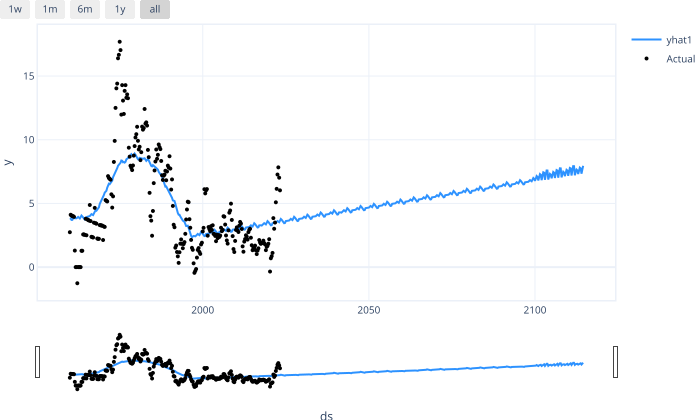

In [47]:
aus_cpi_forecast_visual = aus_cpi_model.plot(aus_cpi_forecast)

WARNING - (py.warnings._showwarnmsg) - /usr/local/lib/python3.12/dist-packages/neuralprophet/plot_forecast_plotly.py:410: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




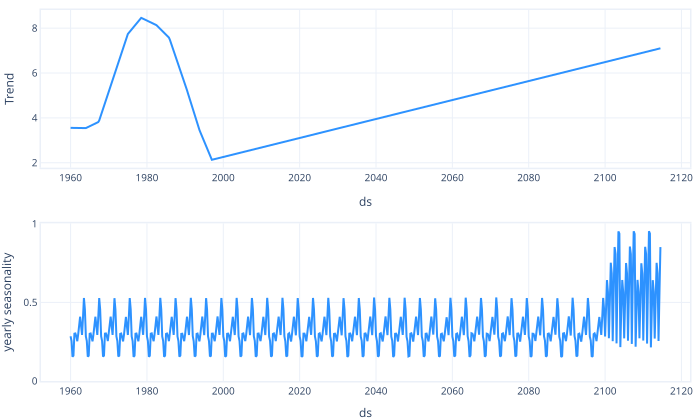

In [48]:
trends_seasons = aus_cpi_model.plot_components(aus_cpi_forecast)

# Using External Regressors - next time we perform causal analysis